## Ito vs. Stratonovich SDEs

Consider a 1D SDE written in Ito form:
$$
dX_t = f(X_t,t)\,dt + g(X_t,t)\,dW_t.
$$

The same SDE can be written in Stratonovich form:
$$
dX_t = \tilde f(X_t,t)\,dt + g(X_t,t)\circ dW_t,
$$
where $\circ dW_t$ denotes the Stratonovich integral.

### Key difference
Ito integrals evaluate the integrand at the left endpoint of each interval.
Stratonovich integrals behave like classical calculus (chain rule holds).

---

### Ito--Stratonovich conversion (1D)
If
$$
dX_t = \tilde f(X_t,t)\,dt + g(X_t,t)\circ dW_t
$$
(Stratonovich), then the equivalent Ito SDE is
$$
dX_t = \left[\tilde f(X_t,t) + \frac{1}{2} g(X_t,t)\frac{\partial g}{\partial x}(X_t,t)\right]dt
      + g(X_t,t)\,dW_t.
$$

Equivalently, if we start from Ito drift $f$, the matching Stratonovich drift is
$$
\tilde f(X_t,t) = f(X_t,t) - \frac{1}{2} g(X_t,t)\frac{\partial g}{\partial x}(X_t,t).
$$

---

### Example: GBM
GBM in Ito form:
$$
dX_t = \mu X_t\,dt + \sigma X_t\,dW_t.
$$
The equivalent Stratonovich form is:
$$
dX_t = \left(\mu - \frac{1}{2}\sigma^2\right) X_t\,dt + \sigma X_t\circ dW_t.
$$

In [1]:
# Imports

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

In [2]:
# Note:
# using the *same* numeric drift mu in both Ito and Stratonovich solve different processes.
# To compare apples-to-apples, I'm applying the drift correction for Stratonovich.

mu = 0.2
sigma = 0.6
x0 = 1.0
T = 1.0

# Discretization
N = 2000
dt = T / N
sqrt_dt = jnp.sqrt(dt)

Note: Simulating a single path first for visualization, then will need to vectorize for many paths.

In [3]:
# Draw Brownian increments ΔW

def brownian_increments(key, N, sqrt_dt):
    """
    Generate ΔW_n ~ N(0, dt) increments.
    This is the core randomness driving the SDE.
    """
    dW = jr.normal(key, shape=(N,)) * sqrt_dt
    return dW

In [4]:
# Ito Euler–Maruyama (baseline)

def ito_euler_maruyama_path(dW):
    """
    Euler–Maruyama for Ito SDE:
      X_{n+1} = X_n + mu*X_n*dt + sigma*X_n*ΔW_n
    Strong order: 0.5 (for general SDEs)
    """
    def step(x, dWn):
        x_next = x + mu * x * dt + sigma * x * dWn
        return x_next, x_next

    # scan iterates the recursion in JAX
    _, xs = jax.lax.scan(step, x0, dW)
    return jnp.concatenate([jnp.array([x0]), xs])

In [5]:
# Ito Milstein (higher strong order than EM)

def ito_milstein_path(dW):
    """
    Milstein scheme for Ito SDE:
      X_{n+1} = X_n + mu*X_n*dt + sigma*X_n*ΔW
               + 0.5 * b(x)*b'(x) * ( (ΔW)^2 - dt )

    Here b(x) = sigma*x, b'(x) = sigma.
    So correction = 0.5 * (sigma*x) * sigma * ((ΔW)^2 - dt)

    Strong order: 1.0 for sufficiently smooth diffusion.
    """
    def step(x, dWn):
        corr = 0.5 * (sigma * x) * sigma * (dWn**2 - dt)
        x_next = x + mu * x * dt + sigma * x * dWn + corr
        return x_next, x_next

    _, xs = jax.lax.scan(step, x0, dW)
    return jnp.concatenate([jnp.array([x0]), xs])

In [6]:
# Stratonovich stochastic Heun / Euler–Heun (SRK-type)

def strat_heun_path(dW):
    """
    Stochastic Heun (Euler–Heun) method for Stratonovich SDE:
      dX = a(X) dt + b(X) ∘ dW

    Update:
      X* = X_n + a(X_n) dt + b(X_n) ΔW
      X_{n+1} = X_n + 0.5*(a(X_n) + a(X*)) dt + 0.5*(b(X_n) + b(X*)) ΔW

    Classic "stochastic RK" flavor for Stratonovich equations.
    Strong order is typically 1.0 in many common settings for Stratonovich SDEs.
    """

    # Use the drift corrected for Stratonovich to represent the SAME GBM as Ito(mu, sigma):
    mu_strat = mu - 0.5 * sigma**2

    def a(x):
        return mu_strat * x

    def b(x):
        return sigma * x

    def step(x, dWn):
        # Predictor ("Euler" step)
        x_star = x + a(x) * dt + b(x) * dWn

        # Corrector (average drift and diffusion)
        x_next = x + 0.5 * (a(x) + a(x_star)) * dt + 0.5 * (b(x) + b(x_star)) * dWn
        return x_next, x_next

    _, xs = jax.lax.scan(step, x0, dW)
    return jnp.concatenate([jnp.array([x0]), xs])

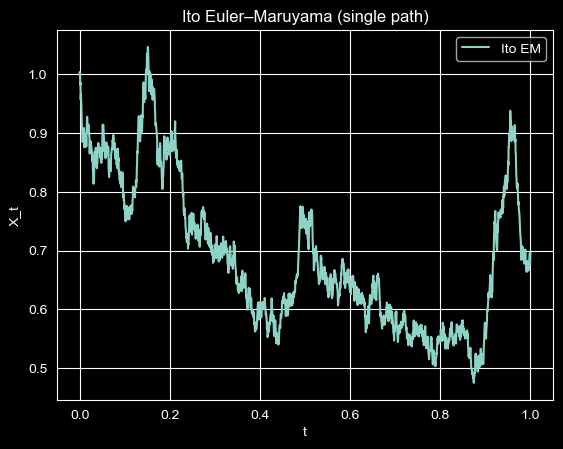

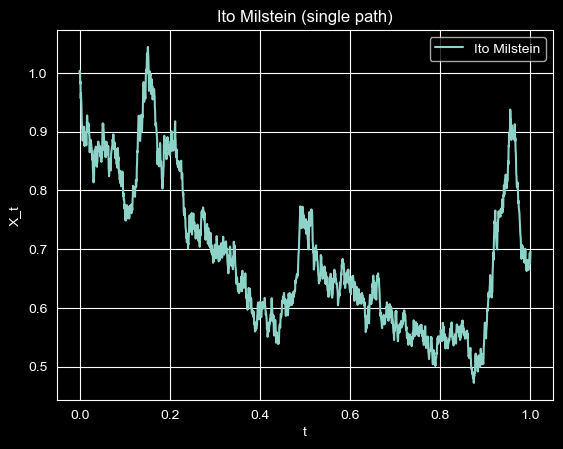

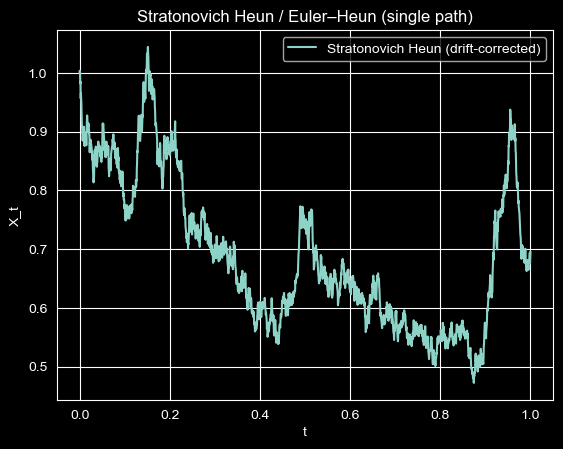

In [7]:
# Single-path comparison

key = jr.PRNGKey(0)
dW = brownian_increments(key, N, sqrt_dt)

tgrid = jnp.linspace(0.0, T, N + 1)

x_em = ito_euler_maruyama_path(dW)
x_mil = ito_milstein_path(dW)
x_heun = strat_heun_path(dW)

plt.figure()
plt.plot(tgrid, x_em, label="Ito EM")
plt.xlabel("t")
plt.ylabel("X_t")
plt.title("Ito Euler–Maruyama (single path)")
plt.legend()
plt.show()

plt.figure()
plt.plot(tgrid, x_mil, label="Ito Milstein")
plt.xlabel("t")
plt.ylabel("X_t")
plt.title("Ito Milstein (single path)")
plt.legend()
plt.show()

plt.figure()
plt.plot(tgrid, x_heun, label="Stratonovich Heun (drift-corrected)")
plt.xlabel("t")
plt.ylabel("X_t")
plt.title("Stratonovich Heun / Euler–Heun (single path)")
plt.legend()
plt.show()